In [1]:
import pyrootutils

root = pyrootutils.setup_root(
    search_from=".",
    indicator=".git",
    pythonpath=True,
    dotenv=True,
)


In [2]:
from itertools import combinations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)


Matplotlib is building the font cache; this may take a moment.


# Data summary and covariate EDA

This notebook is a lightweight place to inspect local single-cell datasets and decide which metadata labels are suitable for figure panels. The emphasis is interpretability, not a fully reproducible benchmark pipeline.


## Pancreas developmental trajectory note

For the pancreas endocrinogenesis dataset, the expected coarse developmental progression is approximately:

`Ductal -> Ngn3 low EP -> Ngn3 high EP -> Pre-endocrine -> Alpha/Beta/Delta/Epsilon`.


In [3]:
data_paths = {
    "embryo_atlas": root / "data" / "HVG_embryoatlas.h5ad",
    "scib_pancreas": root / "data" / "scIBPancreas.h5ad",
    "tabula_muris": root / "data" / "tabula_muris" / "all.h5ad",
    "alles": root / "data" / "Alles_filtered.h5ad",
    "pancreas_day15": root / "data" / "Pancreas" / "endocrinogenesis_day15.h5ad",
}

dataset_overview = []
for name, path in data_paths.items():
    adata = ad.read_h5ad(path, backed="r")
    dataset_overview.append({
        "dataset": name,
        "path": str(path.relative_to(root)),
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "obs_columns": ", ".join(adata.obs.columns),
    })

pd.DataFrame(dataset_overview)


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/anndata/_io/h5ad.py:192: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  adata = AnnData(**d)
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/anndata/_io/h5ad.py:192: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  adata = AnnData(**d)


,dataset,path,n_cells,n_genes,obs_columns
0,embryo_atlas,data/HVG_embryoatlas.h5ad,116312,10000,"cell, barcode, sample, pool, stage, sequencing..."
1,scib_pancreas,data/scIBPancreas.h5ad,16382,19093,"tech, celltype, size_factors"
2,tabula_muris,data/tabula_muris/all.h5ad,57004,18996,"celltype, n_genes, counts"
3,alles,data/Alles_filtered.h5ad,4614,11835,"cell_type1, data_type, cell_ontology_class, n_..."
4,pancreas_day15,data/Pancreas/endocrinogenesis_day15.h5ad,3696,27998,"clusters_coarse, clusters, S_score, G2M_score"


In [4]:
def value_counts_frame(obs, columns, top_n=12):
    rows = []
    for col in columns:
        counts = obs[col].astype(str).value_counts(dropna=False).head(top_n)
        for level, count in counts.items():
            rows.append({
                "covariate": col,
                "level": level,
                "count": int(count),
                "fraction": count / len(obs),
            })
    return pd.DataFrame(rows)


def cramers_v(x, y):
    table = pd.crosstab(x.astype(str), y.astype(str))
    if min(table.shape) <= 1:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))


def association_matrix(obs, columns):
    mat = pd.DataFrame(np.eye(len(columns)), index=columns, columns=columns)
    for a, b in combinations(columns, 2):
        value = cramers_v(obs[a], obs[b])
        mat.loc[a, b] = value
        mat.loc[b, a] = value
    return mat.astype(float)


def normalized_crosstab(obs, row, col):
    counts = pd.crosstab(obs[row].astype(str), obs[col].astype(str))
    return counts.div(counts.sum(axis=1), axis=0)


def plot_association_heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(0.75 * len(mat.columns) + 4, 0.65 * len(mat.index) + 3))
    sns.heatmap(mat, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="mako", square=True, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


## Embryo atlas covariates

Covariate interpretation from `HVG_embryoatlas.h5ad` metadata:

- `celltype`: curated biological cell identity label. Good candidate for a biology-control row.
- `stage`: embryonic collection/developmental time, from `E6.5` to `E8.5`, plus `mixed_gastrulation`. Biologically meaningful, but not independent of sample design.
- `theiler`: coarser developmental staging label. In this file it is almost a deterministic recoding of `stage`.
- `sequencing.batch`: technical sequencing batch. Good candidate for a technical-control row.
- `sample` and `pool`: sample/preparation identifiers. These are useful confounding diagnostics, not usually labels to control directly.
- `cluster`, `cluster.sub`, `cluster.stage`, `cluster.theiler`: analysis-derived cluster labels. Avoid these for the main disentanglement figure unless the manuscript explicitly uses those cluster definitions.

The key question for Figure 2 is whether off-diagonal heatmap entries reflect model leakage or dataset confounding. The association checks below help separate those two explanations.


In [7]:
embryo = ad.read_h5ad(data_paths["embryo_atlas"], backed="r")
display(embryo.X.shape)
embryo_covariates = [
    "celltype",
    "stage",
    "theiler",
    "sequencing.batch",
    "sample",
    "pool",
]

summary = pd.DataFrame({
    "covariate": embryo_covariates,
    "n_levels": [embryo.obs[col].nunique(dropna=False) for col in embryo_covariates],
    "example_levels": [", ".join(map(str, embryo.obs[col].astype(str).unique()[:6])) for col in embryo_covariates],
})
summary


(116312, 10000)

,covariate,n_levels,example_levels
0,celltype,37,"Epiblast, Primitive Streak, ExE ectoderm, Visc..."
1,stage,10,"E6.5, E7.5, E6.75, E7.75, E7.0, E8.0"
2,theiler,5,"TS9, TS11, TS10, TS12, TS9-10"
3,sequencing.batch,3,"1, 2, 3"
4,sample,36,"1, 2, 3, 4, 5, 6"
5,pool,25,"1, 2, 3, 4, 5, 6"


In [6]:
value_counts_frame(embryo.obs, embryo_covariates, top_n=10)


,covariate,level,count,fraction
0,celltype,Epiblast,14619,0.125688
1,celltype,ExE ectoderm,11758,0.101090
2,celltype,ExE endoderm,9339,0.080293
3,celltype,Primitive Streak,7265,0.062461
4,celltype,Rostral neurectoderm,5392,0.046358
5,celltype,Nascent mesoderm,5028,0.043229
6,celltype,Mesenchyme,4979,0.042807
7,celltype,Forebrain/Midbrain/Hindbrain,4854,0.041733
8,celltype,Paraxial mesoderm,3811,0.032765
9,celltype,Intermediate mesoderm,3551,0.030530


In [7]:
embryo_assoc = association_matrix(embryo.obs, embryo_covariates)
embryo_assoc


,celltype,stage,theiler,sequencing.batch,sample,pool
celltype,1.000000,0.364946,0.467828,0.253524,0.194999,0.2348
stage,0.364946,1.000000,1.000000,0.683748,1.000000,1.0000
theiler,0.467828,1.000000,1.000000,0.475453,1.000000,1.0000
sequencing.batch,0.253524,0.683748,0.475453,1.000000,1.000000,1.0000
sample,0.194999,1.000000,1.000000,1.000000,1.000000,1.0000
pool,0.234800,1.000000,1.000000,1.000000,1.000000,1.0000


(<Figure size 850x690 with 2 Axes>,
 <Axes: title={'center': 'Embryo atlas covariate association (Cramer V)'}>)

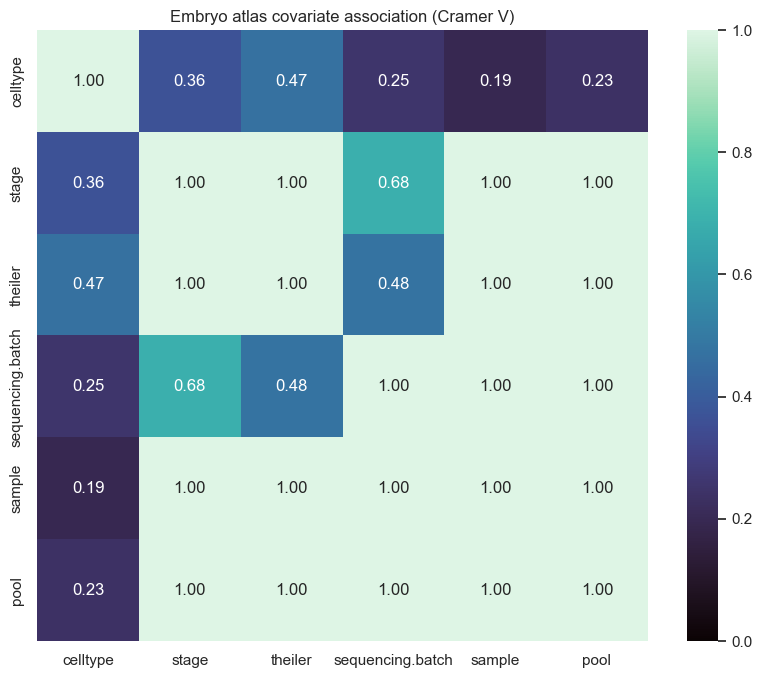

In [8]:
plot_association_heatmap(
    embryo_assoc,
    "Embryo atlas covariate association (Cramer V)",
)


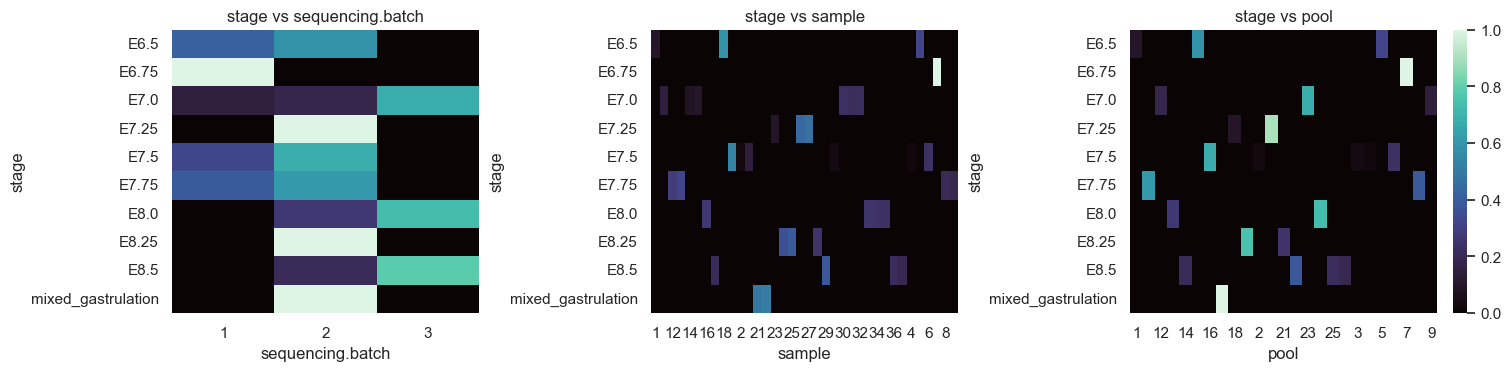

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
for ax, col in zip(axes, ["sequencing.batch", "sample", "pool"]):
    table = normalized_crosstab(embryo.obs, "stage", col)
    sns.heatmap(table, cmap="mako", vmin=0, vmax=1, cbar=ax is axes[-1], ax=ax)
    ax.set_title(f"stage vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("stage")
plt.show()


The embryo atlas is useful for biology, but `stage` is tightly coupled to sample/pool and strongly coupled to `sequencing.batch`. If `stage` is used in a Figure 2 predictability heatmap, interpret it as a diagnostic developmental covariate rather than a clean independent control label.


## scIB pancreas covariates

`scIBPancreas.h5ad` has a simpler label structure for Figure 2:

- `celltype`: pancreatic biological cell identity.
- `tech`: sequencing technology/platform, a clean technical batch label.

This dataset is a strong candidate for the main latent-disentanglement heatmap because the biological and technical labels are interpretable and less entangled than embryo `stage` and sequencing batch.


In [10]:
scib = ad.read_h5ad(data_paths["scib_pancreas"], backed="r")
scib_covariates = ["celltype", "tech"]

pd.DataFrame({
    "covariate": scib_covariates,
    "n_levels": [scib.obs[col].nunique(dropna=False) for col in scib_covariates],
    "example_levels": [", ".join(map(str, scib.obs[col].astype(str).unique()[:8])) for col in scib_covariates],
})


,covariate,n_levels,example_levels
0,celltype,14,"gamma, acinar, alpha, delta, beta, ductal, end..."
1,tech,9,"celseq, celseq2, fluidigmc1, smartseq2, inDrop..."


In [11]:
value_counts_frame(scib.obs, scib_covariates, top_n=14)


,covariate,level,count,fraction
0,celltype,alpha,5493,0.335307
1,celltype,beta,4169,0.254487
2,celltype,ductal,2142,0.130753
3,celltype,acinar,1669,0.101880
4,celltype,delta,1055,0.064400
5,celltype,gamma,699,0.042669
6,celltype,activated_stellate,464,0.028324
7,celltype,endothelial,313,0.019106
8,celltype,quiescent_stellate,193,0.011781
9,celltype,macrophage,79,0.004822


In [12]:
scib_assoc = association_matrix(scib.obs, scib_covariates)
scib_assoc


,celltype,tech
celltype,1.000000,0.189765
tech,0.189765,1.000000


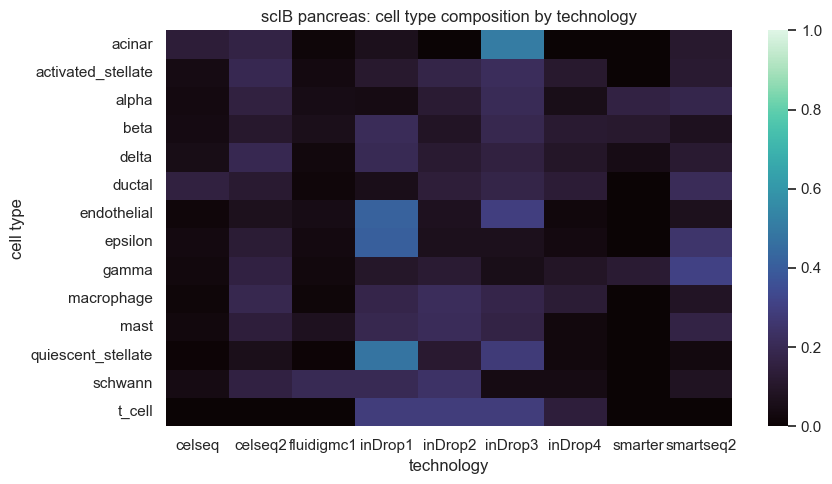

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    normalized_crosstab(scib.obs, "celltype", "tech"),
    cmap="mako",
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_title("scIB pancreas: cell type composition by technology")
ax.set_xlabel("technology")
ax.set_ylabel("cell type")
plt.tight_layout()
